# Microfinance Fraud Detection using Machine Learning

## Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to explore the dataset visually, identify hidden patterns, detect anomalies, understand feature relationships, and generate business insights that support fraud detection.

### Tasks

- Analyze target variable
- Study customer demographics
- Explore loan characteristics
- Analyze financial behavior
- Study digital activity
- Analyze fraud patterns
- Generate business insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
df = pd.read_csv(r'C:\Users\Dinesh\OneDrive\Desktop\Microfinance-Fraud-Detection\data\raw\microfinance_fraud_detection_dataset.csv')
df.head()
print(df.shape)
df.info()

(50000, 95)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 95 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                50000 non-null  str    
 1   customer_id                   50000 non-null  str    
 2   branch_id                     50000 non-null  str    
 3   loan_id                       50000 non-null  str    
 4   customer_age                  50000 non-null  int64  
 5   gender                        50000 non-null  str    
 6   marital_status                50000 non-null  str    
 7   education_level               50000 non-null  str    
 8   occupation                    50000 non-null  str    
 9   annual_income                 50000 non-null  float64
 10  monthly_expenses              50000 non-null  float64
 11  credit_score                  50000 non-null  int64  
 12  years_with_institution        50000 non-null  float64
 13  

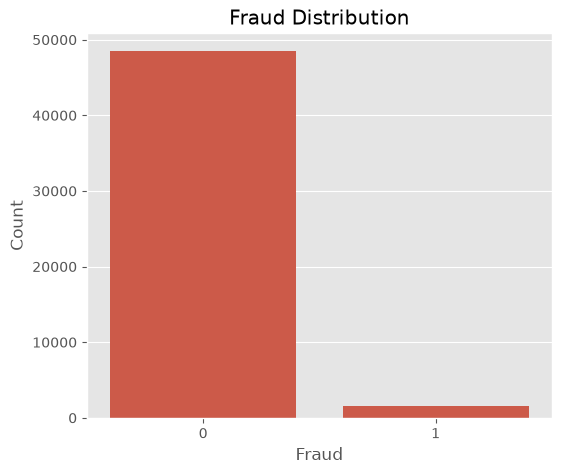

In [5]:
plt.figure(figsize=(6,5))

sns.countplot(x="is_fraud",data=df)

plt.title("Fraud Distribution")
plt.xlabel("Fraud")
plt.ylabel("Count")

plt.show()

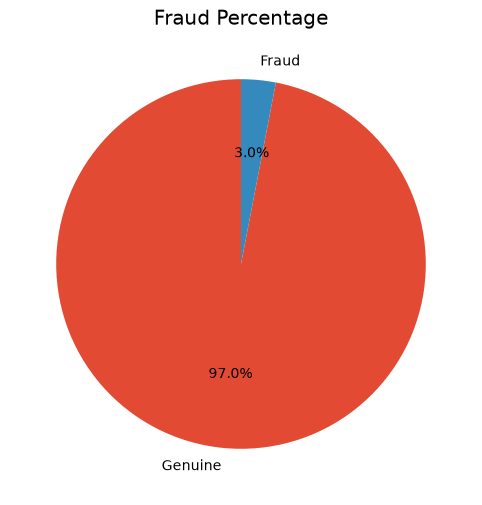

In [6]:
fraud=df["is_fraud"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
fraud,
labels=["Genuine","Fraud"],
autopct="%1.1f%%",
startangle=90
)

plt.title("Fraud Percentage")

plt.show()

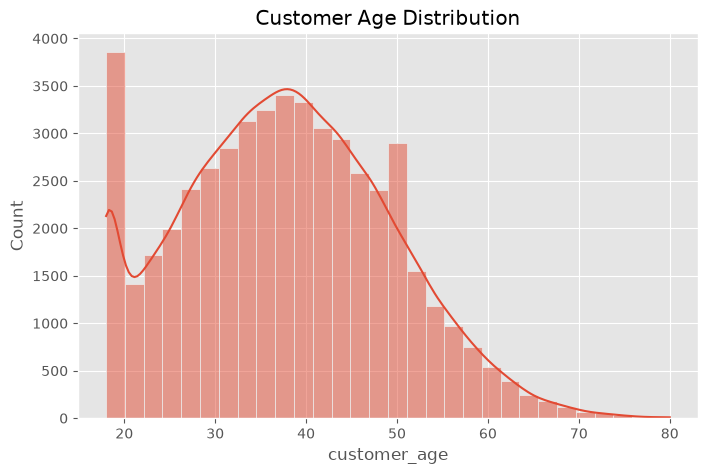

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df["customer_age"],bins=30,kde=True)

plt.title("Customer Age Distribution")

plt.show()

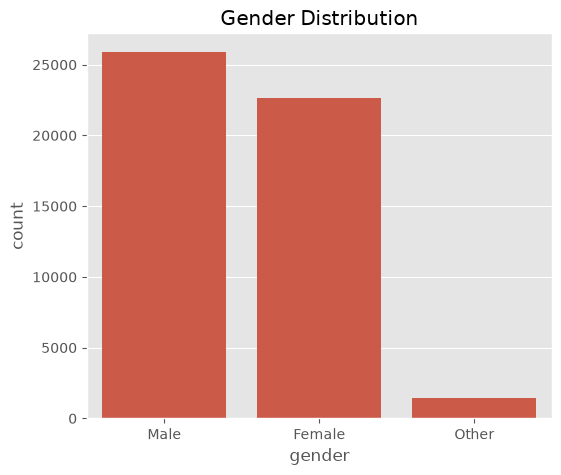

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(x="gender",data=df)

plt.title("Gender Distribution")

plt.show()

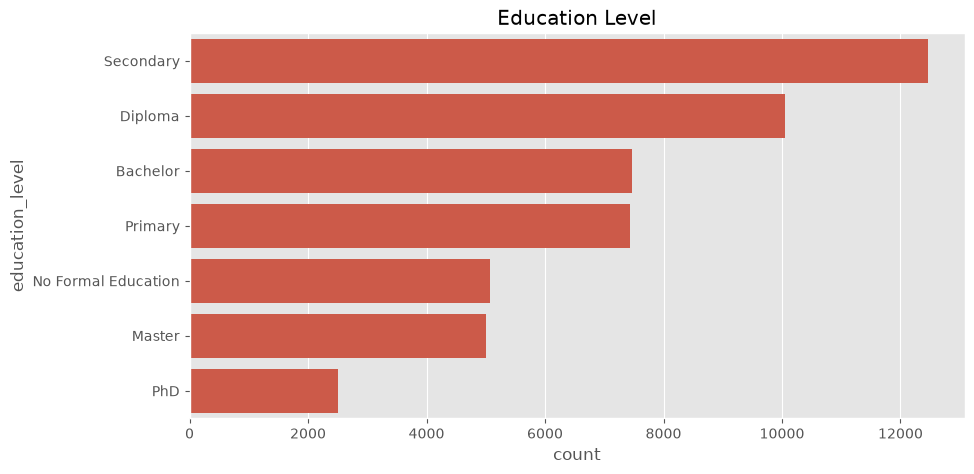

In [9]:
plt.figure(figsize=(10,5))

sns.countplot(
y="education_level",
data=df,
order=df["education_level"].value_counts().index
)

plt.title("Education Level")

plt.show()

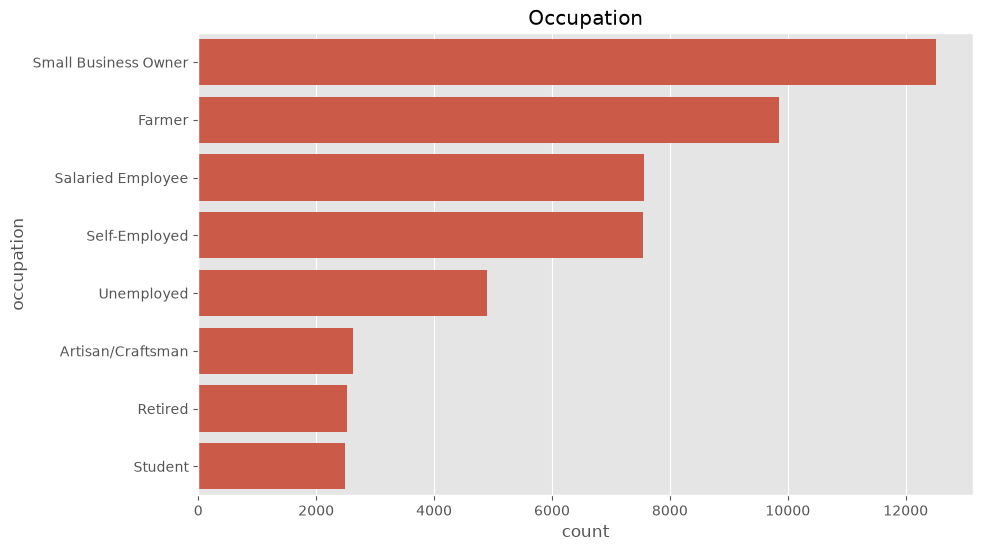

In [10]:
plt.figure(figsize=(10,6))

sns.countplot(
y="occupation",
data=df,
order=df["occupation"].value_counts().index
)

plt.title("Occupation")

plt.show()

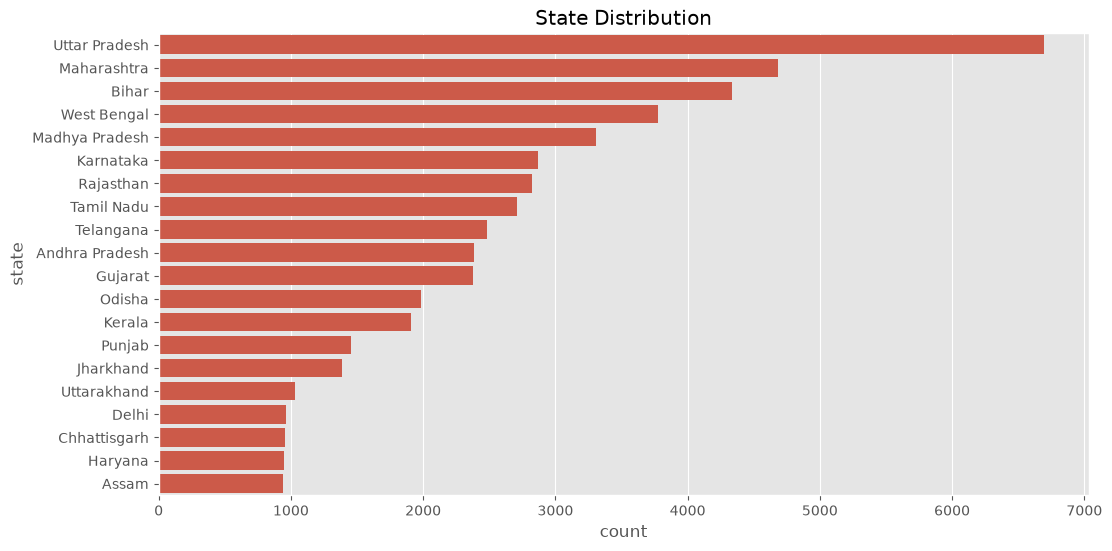

In [11]:
plt.figure(figsize=(12,6))

sns.countplot(
y="state",
data=df,
order=df["state"].value_counts().index
)

plt.title("State Distribution")

plt.show()

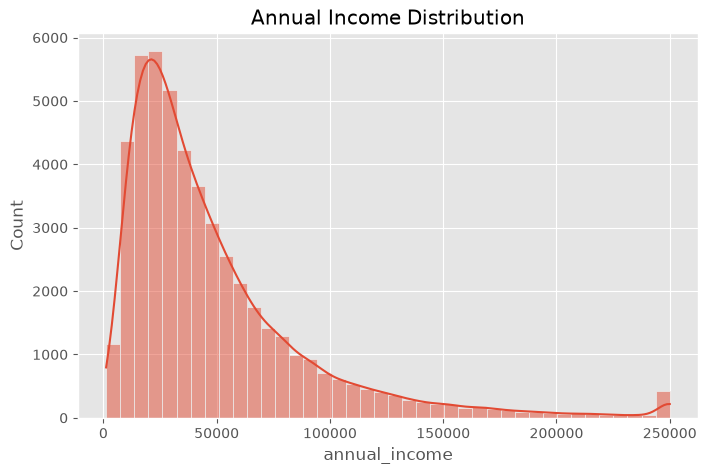

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["annual_income"],bins=40,kde=True)

plt.title("Annual Income Distribution")

plt.show()

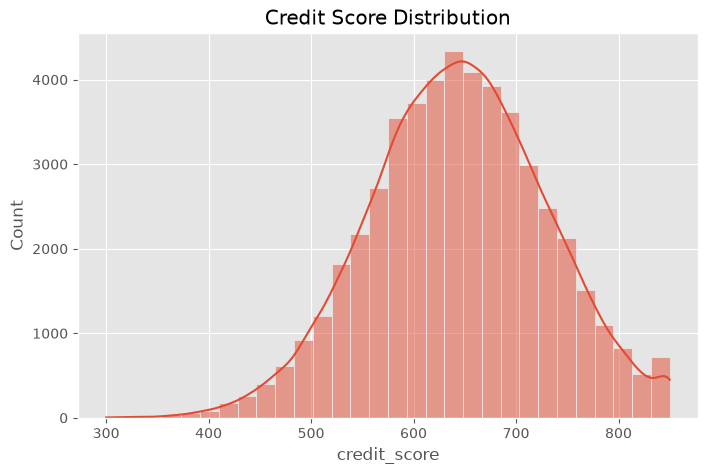

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["credit_score"],bins=30,kde=True)

plt.title("Credit Score Distribution")

plt.show()

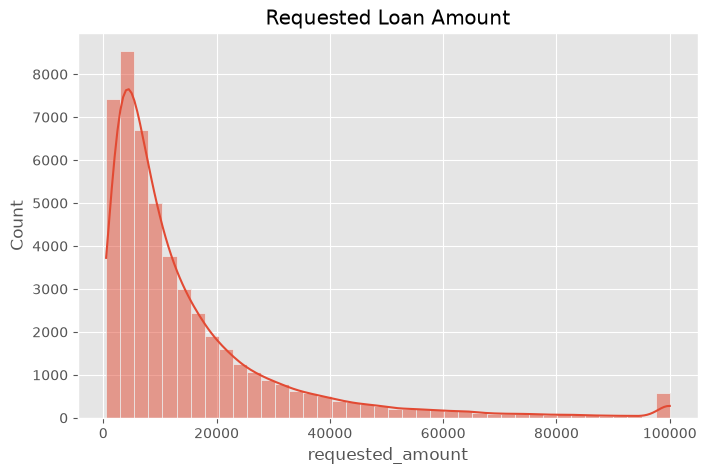

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["requested_amount"],bins=40,kde=True)

plt.title("Requested Loan Amount")

plt.show()

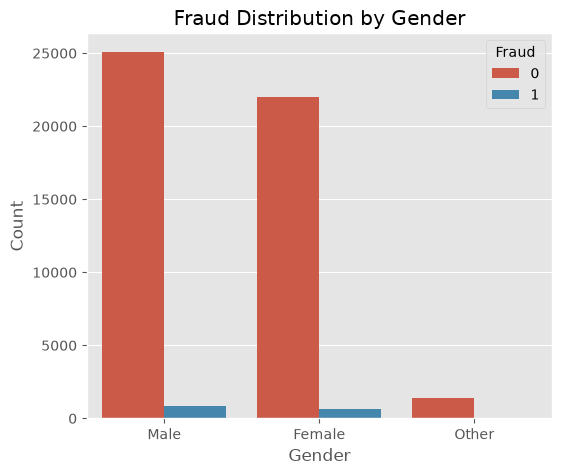

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="gender",
    hue="is_fraud",
    data=df
)

plt.title("Fraud Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.legend(title="Fraud")

plt.show()

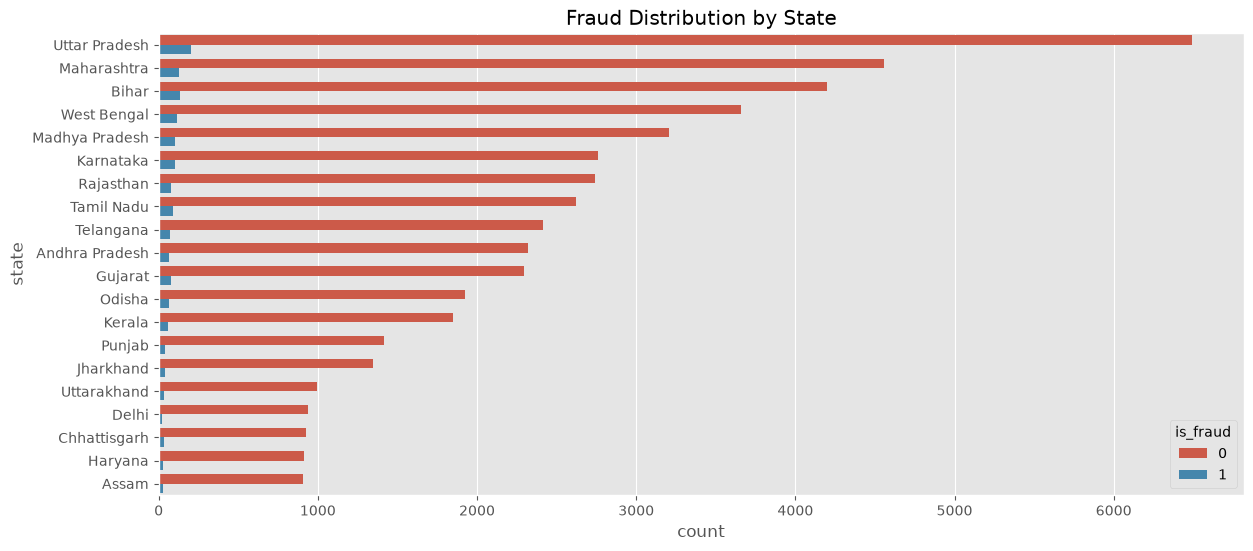

In [16]:
plt.figure(figsize=(14,6))

sns.countplot(
    y="state",
    hue="is_fraud",
    data=df,
    order=df["state"].value_counts().index
)

plt.title("Fraud Distribution by State")

plt.show()

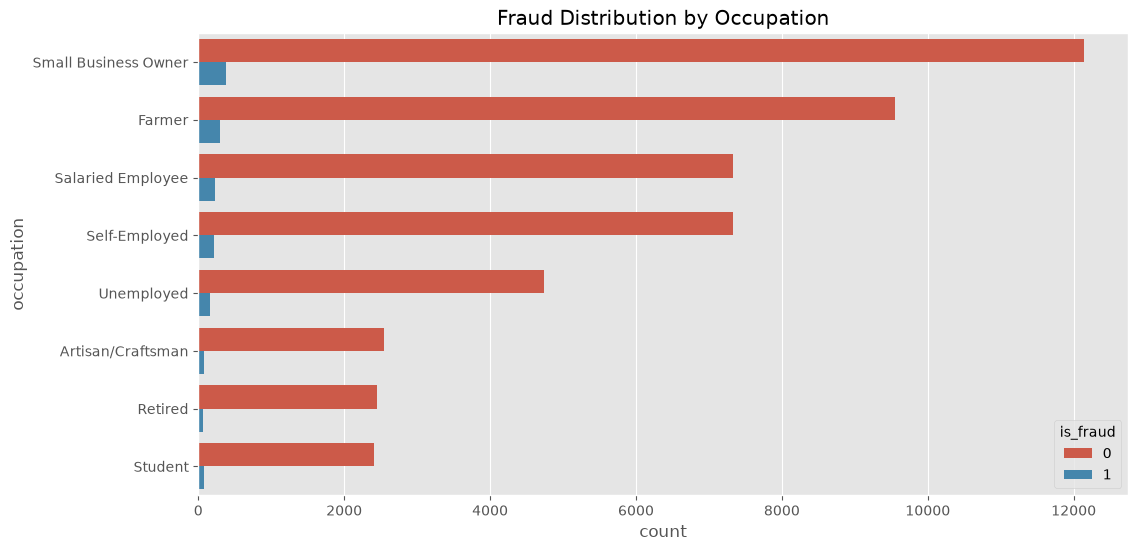

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="occupation",
    hue="is_fraud",
    data=df,
    order=df["occupation"].value_counts().index
)

plt.title("Fraud Distribution by Occupation")

plt.show()

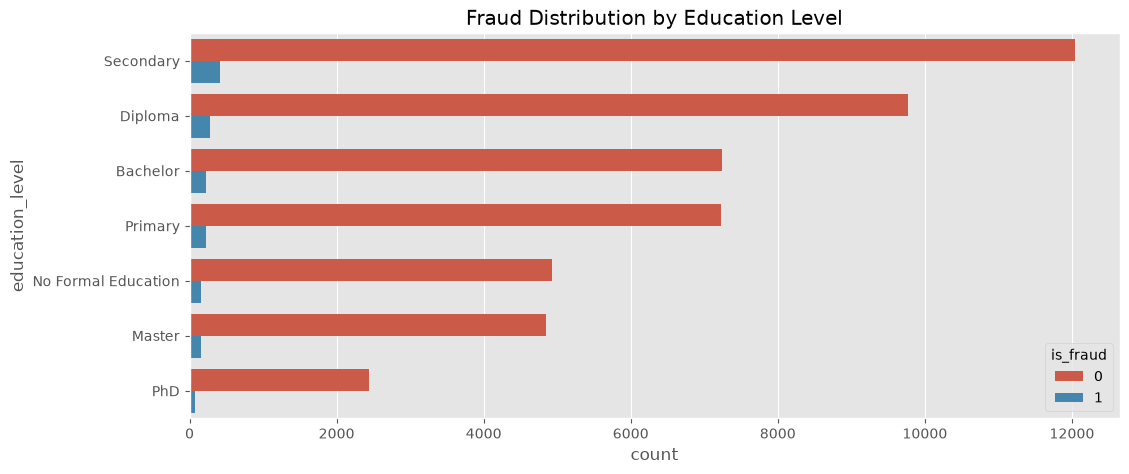

In [18]:
plt.figure(figsize=(12,5))

sns.countplot(
    y="education_level",
    hue="is_fraud",
    data=df,
    order=df["education_level"].value_counts().index
)

plt.title("Fraud Distribution by Education Level")

plt.show()

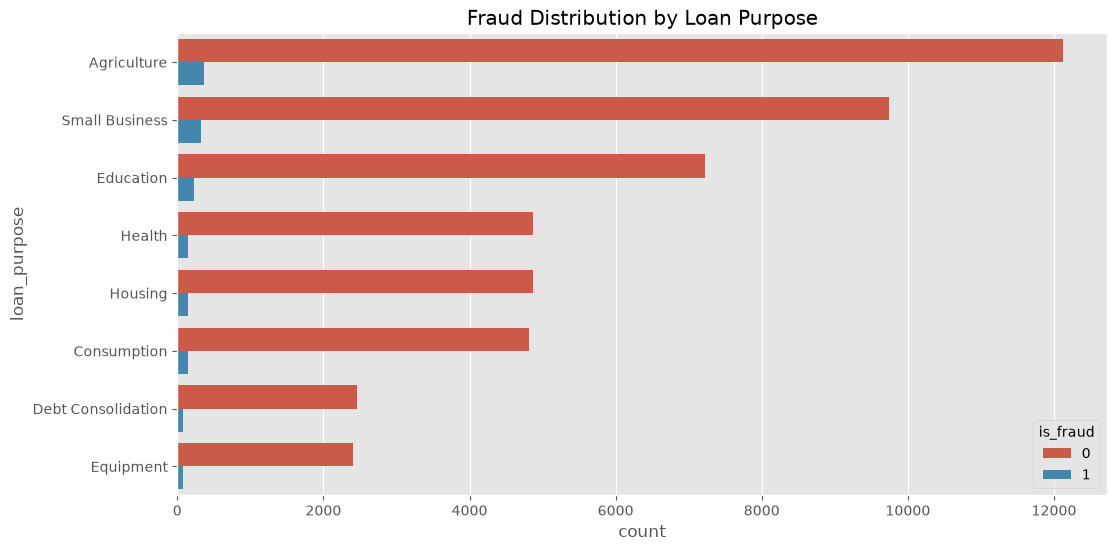

In [19]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="loan_purpose",
    hue="is_fraud",
    data=df,
    order=df["loan_purpose"].value_counts().index
)

plt.title("Fraud Distribution by Loan Purpose")

plt.show()

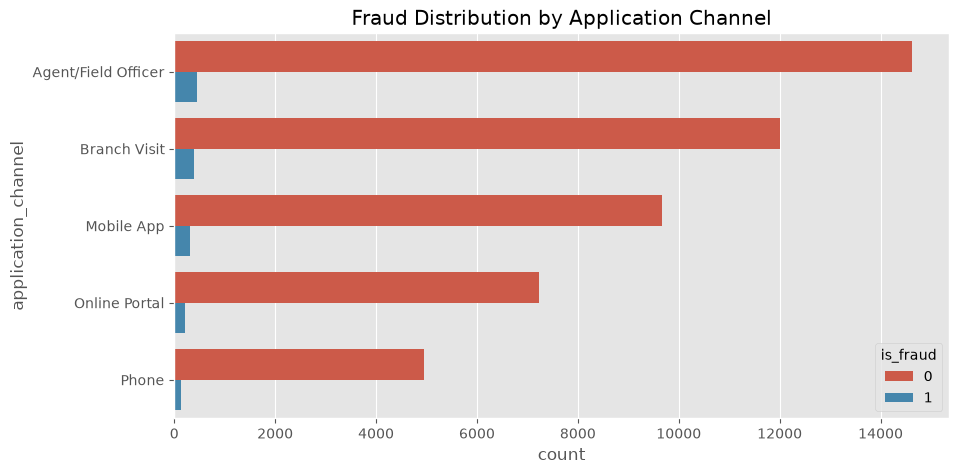

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="application_channel",
    hue="is_fraud",
    data=df,
    order=df["application_channel"].value_counts().index
)

plt.title("Fraud Distribution by Application Channel")

plt.show()

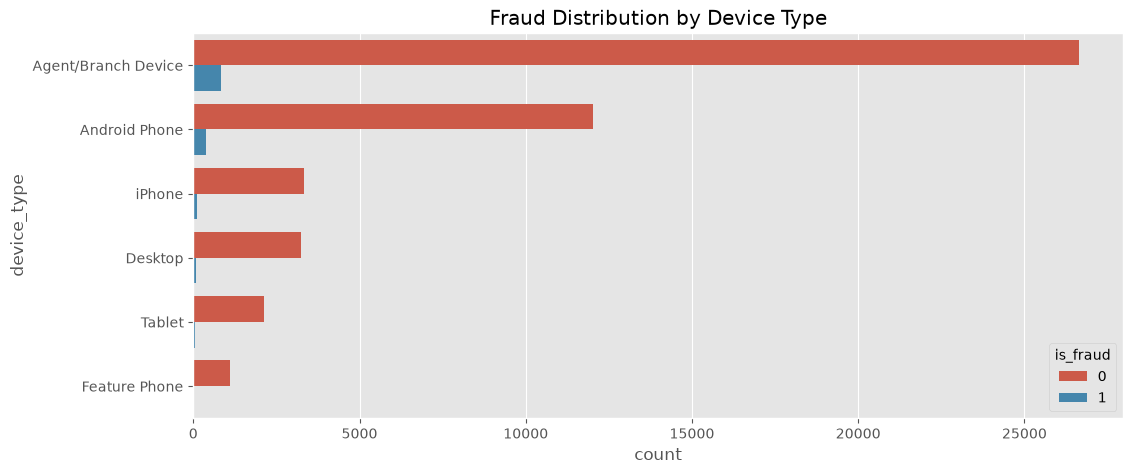

In [21]:
plt.figure(figsize=(12,5))

sns.countplot(
    y="device_type",
    hue="is_fraud",
    data=df,
    order=df["device_type"].value_counts().index
)

plt.title("Fraud Distribution by Device Type")

plt.show()

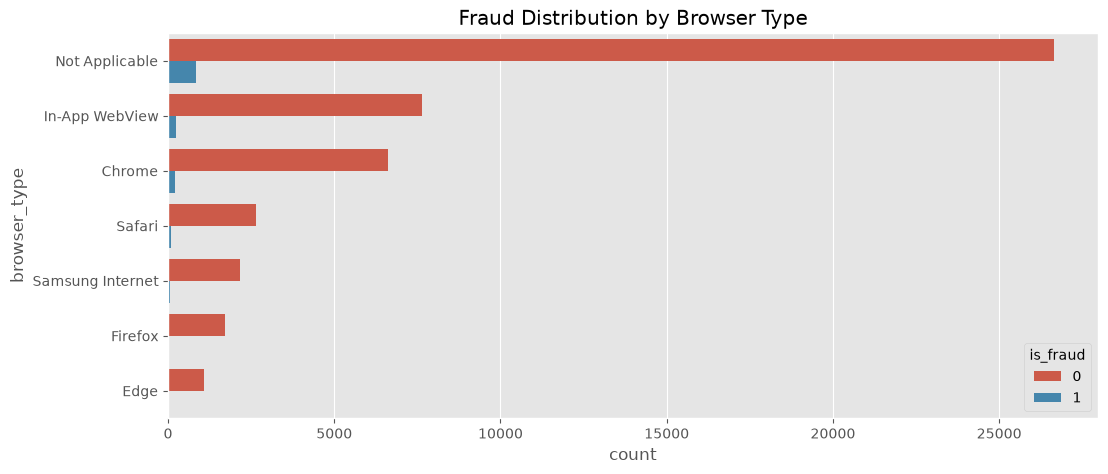

In [22]:
plt.figure(figsize=(12,5))

sns.countplot(
    y="browser_type",
    hue="is_fraud",
    data=df,
    order=df["browser_type"].value_counts().index
)

plt.title("Fraud Distribution by Browser Type")

plt.show()

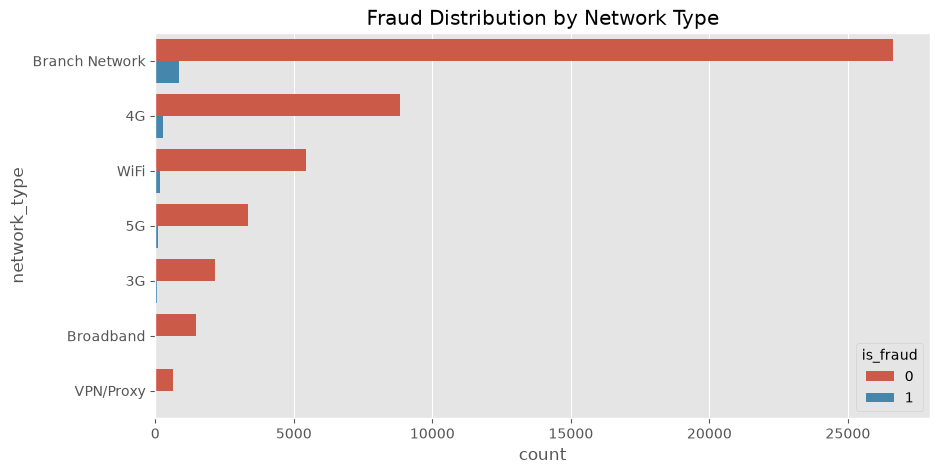

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="network_type",
    hue="is_fraud",
    data=df,
    order=df["network_type"].value_counts().index
)

plt.title("Fraud Distribution by Network Type")

plt.show()

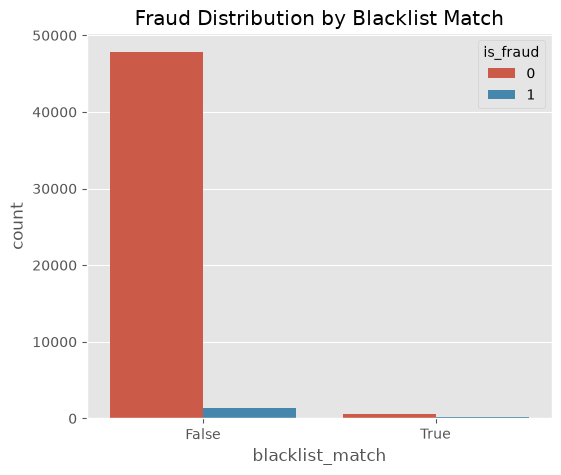

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="blacklist_match",
    hue="is_fraud",
    data=df
)

plt.title("Fraud Distribution by Blacklist Match")

plt.show()

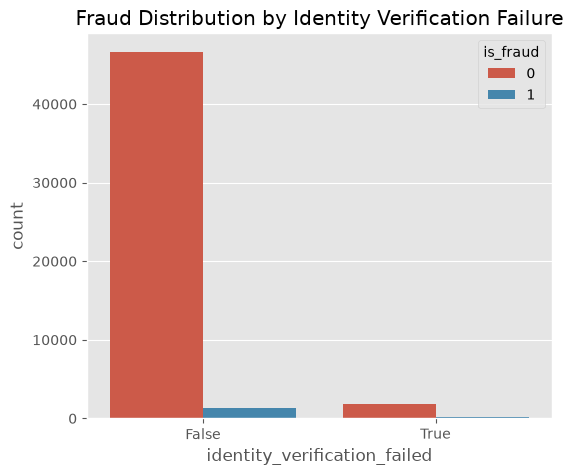

In [25]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="identity_verification_failed",
    hue="is_fraud",
    data=df
)

plt.title("Fraud Distribution by Identity Verification Failure")

plt.show()

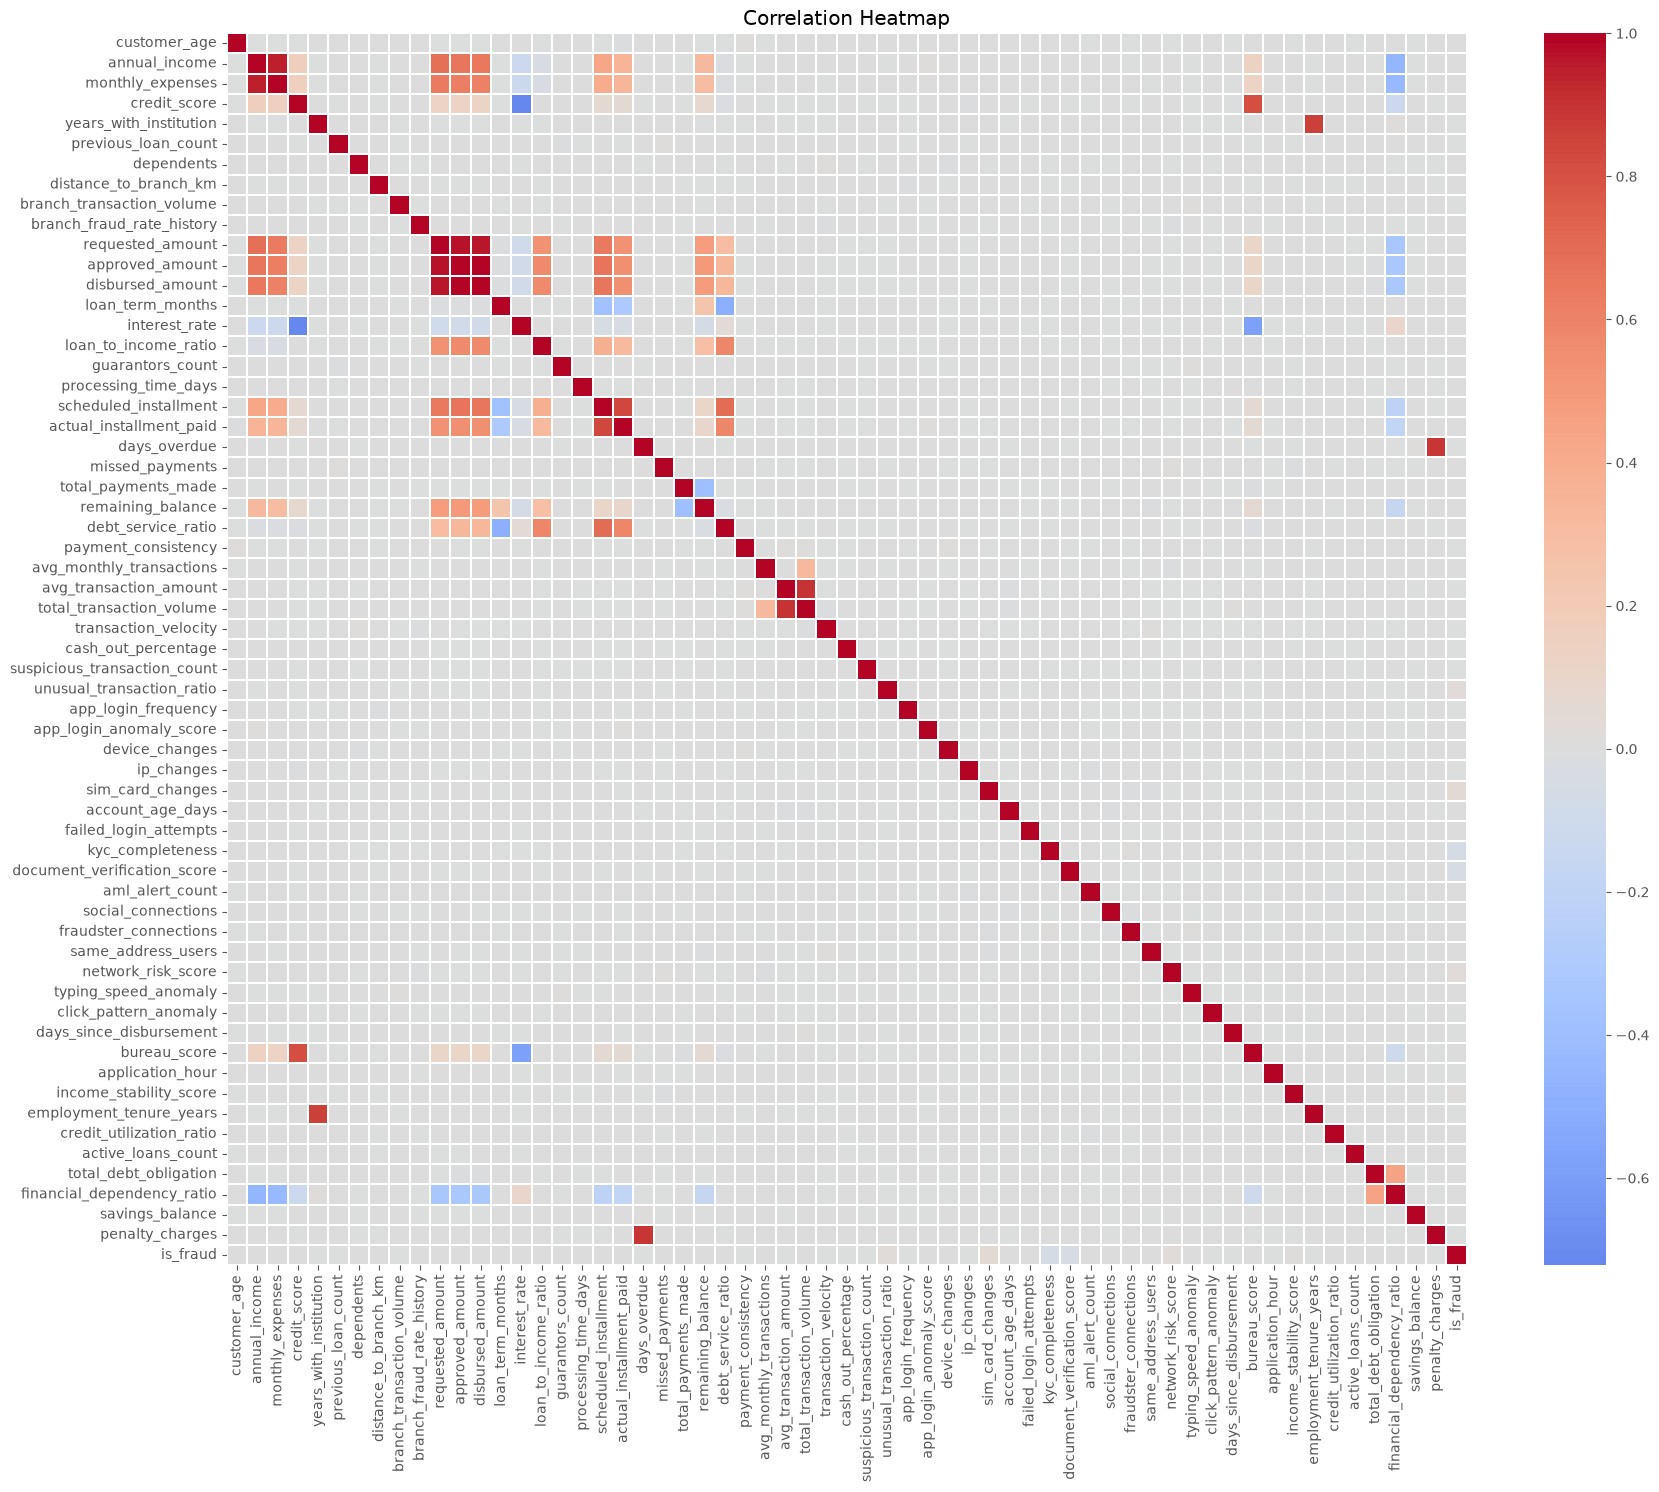

In [27]:
plt.figure(figsize=(20,16))

numerical_df = df.select_dtypes(include=["int64", "float64"])

corr = numerical_df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Heatmap")

plt.show()

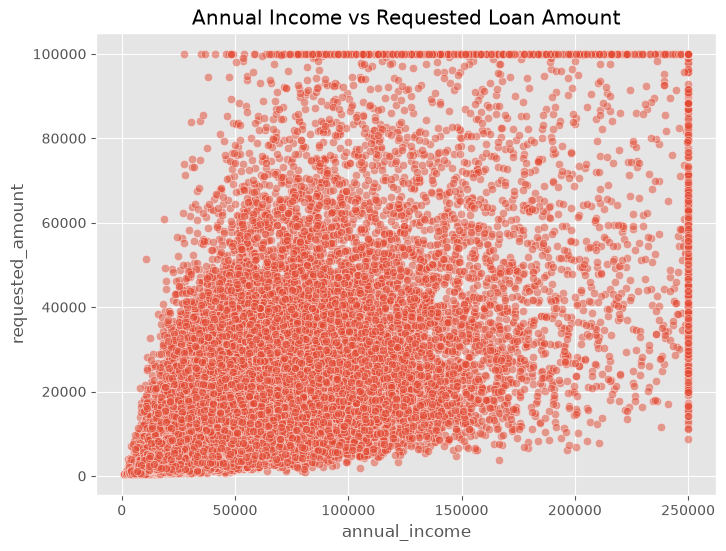

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="annual_income",
    y="requested_amount",
    data=df,
    alpha=0.5
)

plt.title("Annual Income vs Requested Loan Amount")

plt.show()

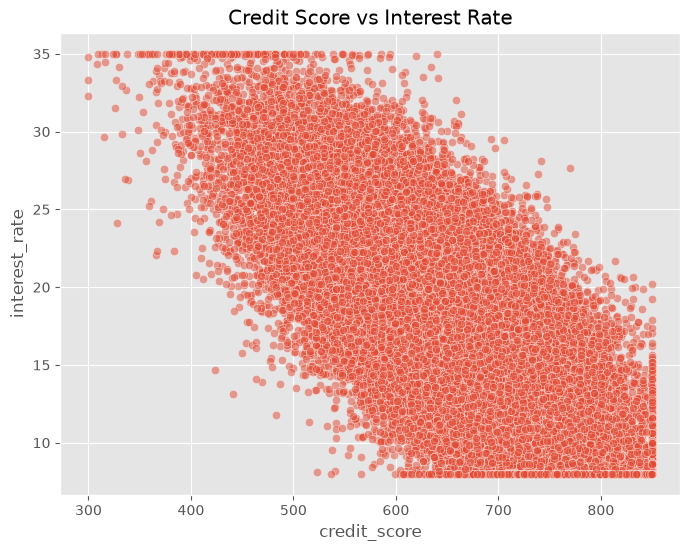

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="credit_score",
    y="interest_rate",
    data=df,
    alpha=0.5
)

plt.title("Credit Score vs Interest Rate")

plt.show()

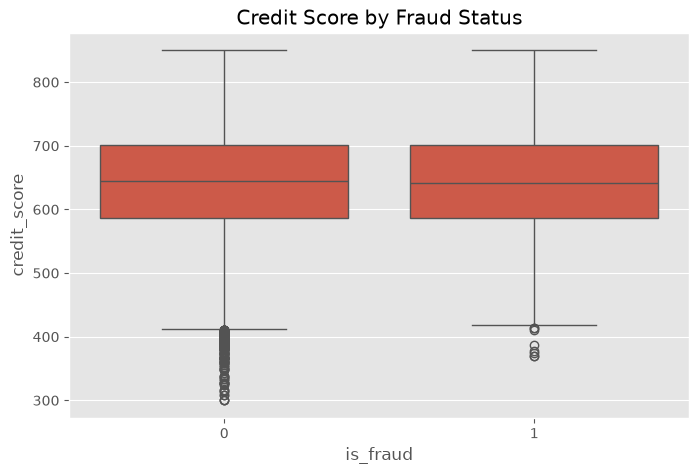

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="credit_score",
    data=df
)

plt.title("Credit Score by Fraud Status")

plt.show()

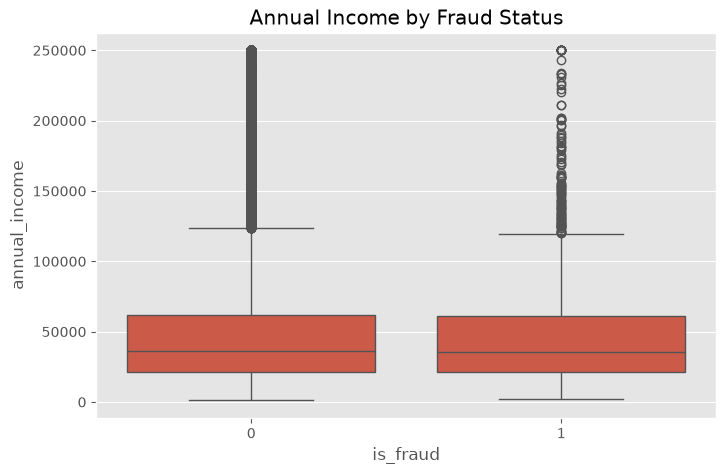

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="annual_income",
    data=df
)

plt.title("Annual Income by Fraud Status")

plt.show()

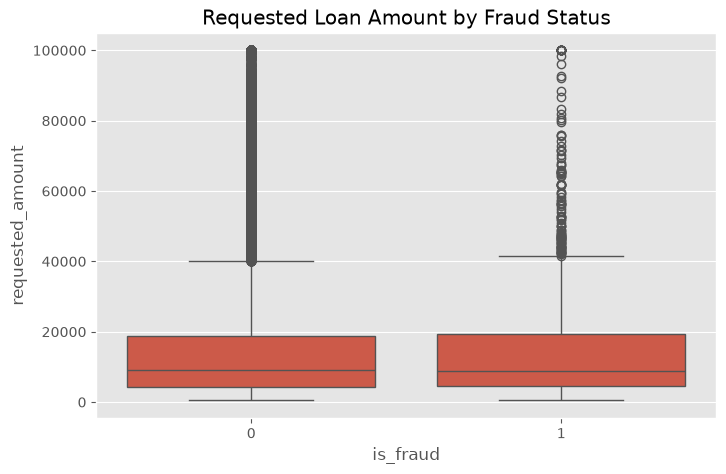

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="requested_amount",
    data=df
)

plt.title("Requested Loan Amount by Fraud Status")

plt.show()

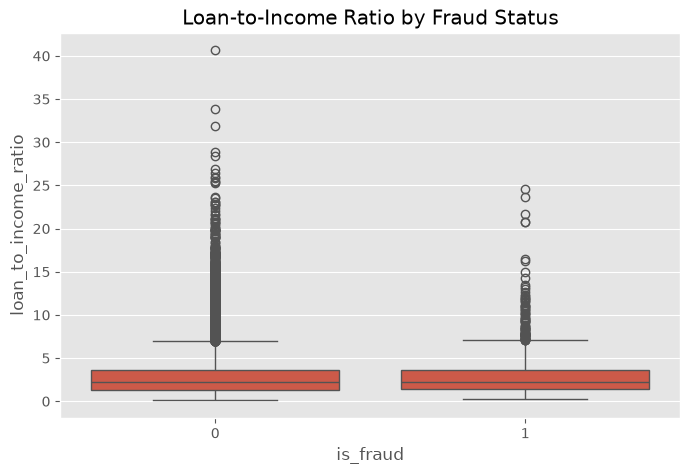

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="loan_to_income_ratio",
    data=df
)

plt.title("Loan-to-Income Ratio by Fraud Status")

plt.show()

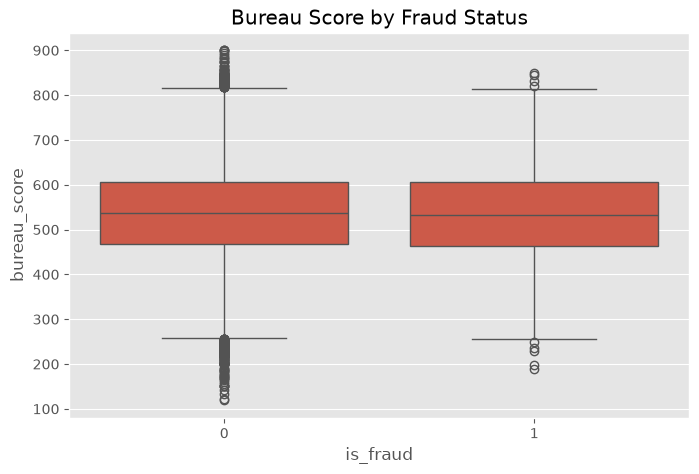

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="bureau_score",
    data=df
)

plt.title("Bureau Score by Fraud Status")

plt.show()

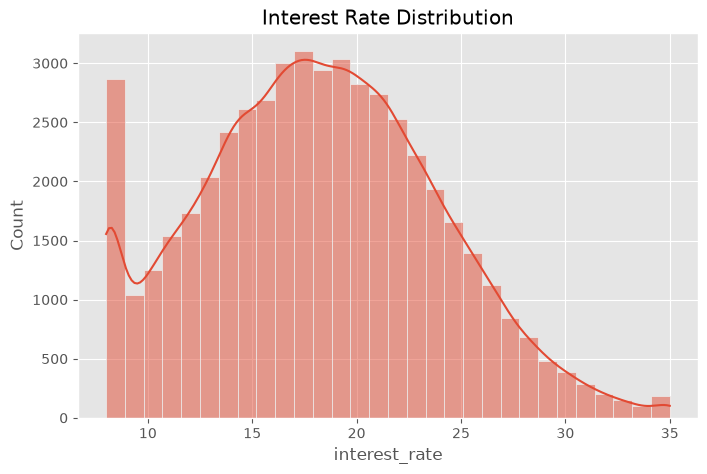

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["interest_rate"],
    bins=30,
    kde=True
)

plt.title("Interest Rate Distribution")

plt.show()

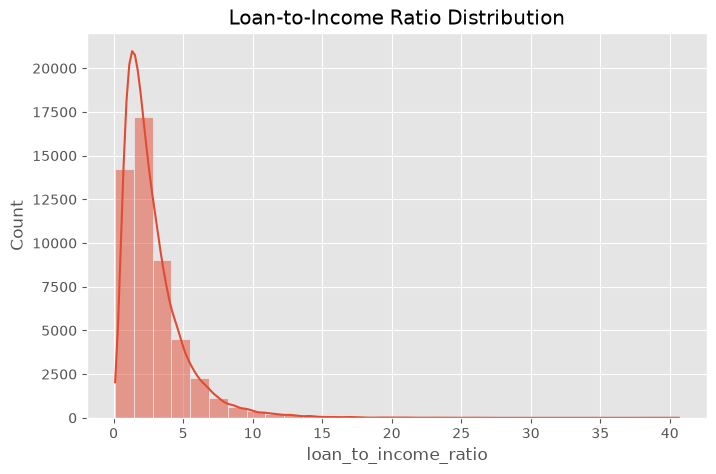

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["loan_to_income_ratio"],
    bins=30,
    kde=True
)

plt.title("Loan-to-Income Ratio Distribution")

plt.show()

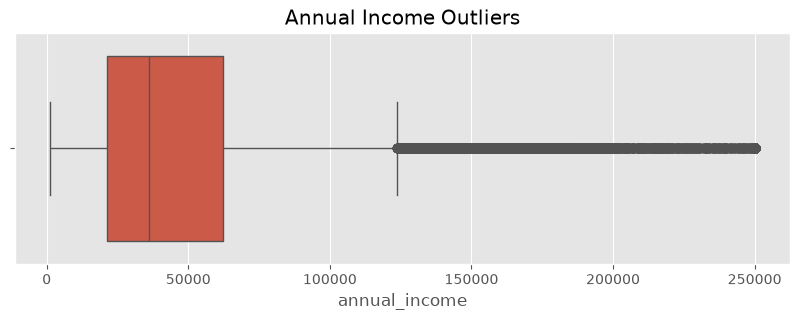

In [37]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df["annual_income"]
)

plt.title("Annual Income Outliers")

plt.show()

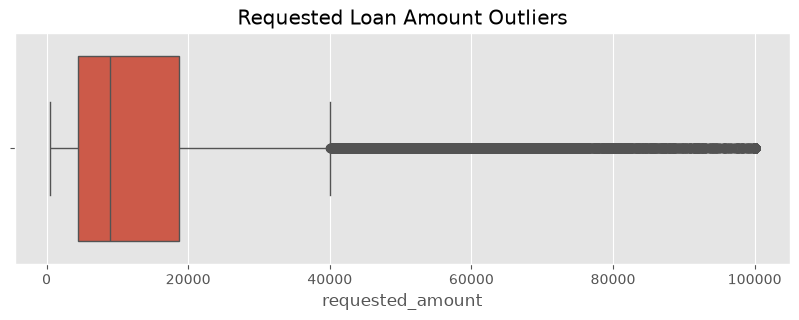

In [38]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df["requested_amount"]
)

plt.title("Requested Loan Amount Outliers")

plt.show()

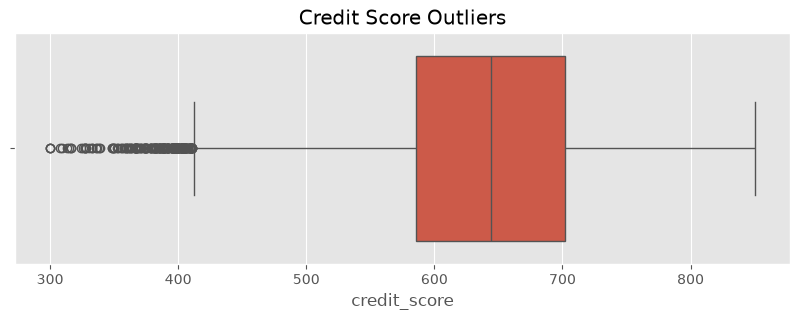

In [39]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df["credit_score"]
)

plt.title("Credit Score Outliers")

plt.show()

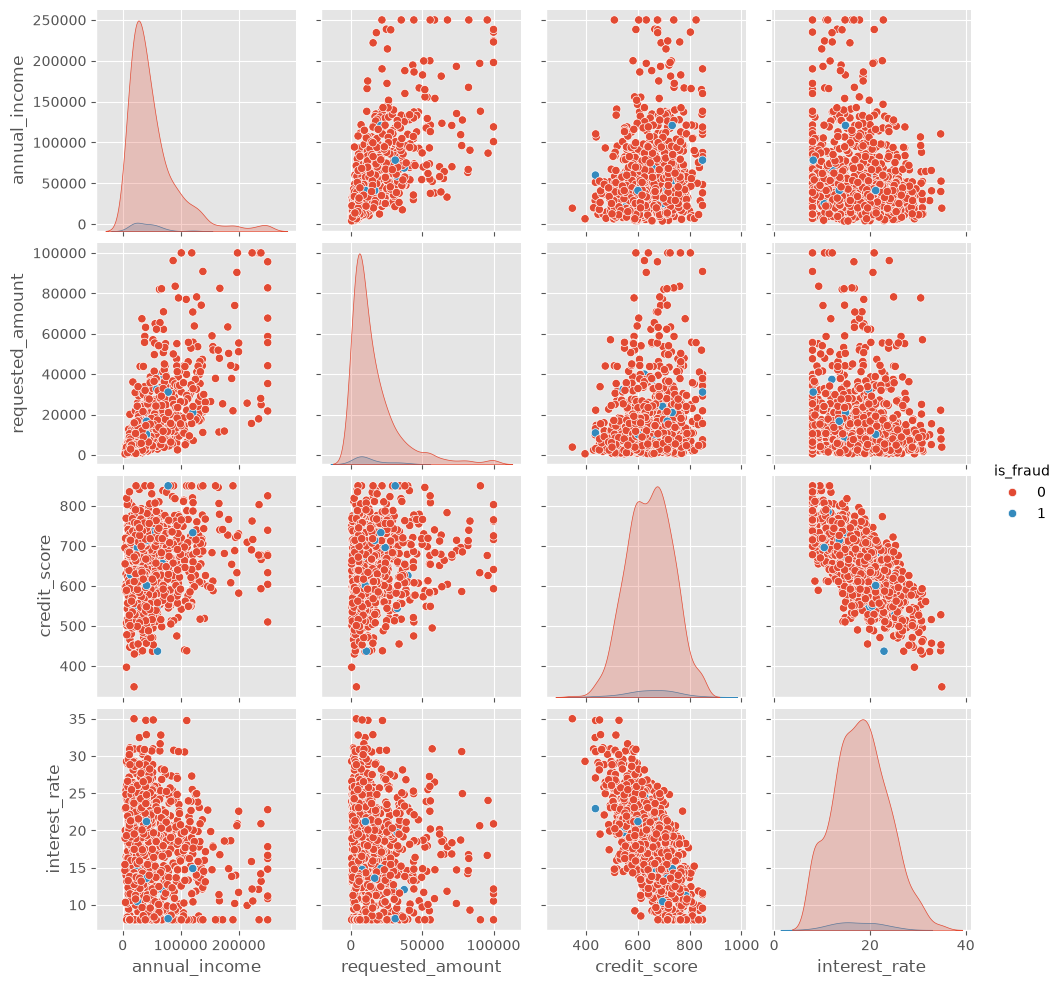

In [40]:
sample_df = df.sample(1000, random_state=42)

sns.pairplot(
    sample_df[
        [
            "annual_income",
            "requested_amount",
            "credit_score",
            "interest_rate",
            "is_fraud"
        ]
    ],
    hue="is_fraud"
)

plt.show()

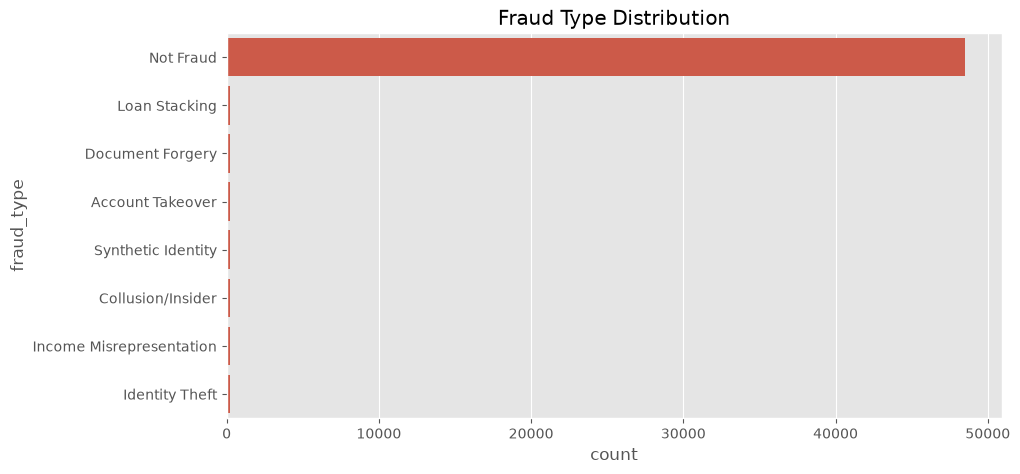

In [41]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="fraud_type",
    data=df,
    order=df["fraud_type"].value_counts().index
)

plt.title("Fraud Type Distribution")

plt.show()

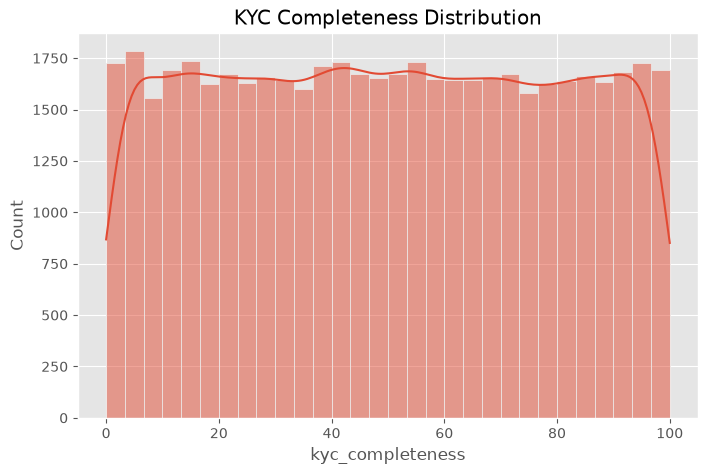

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["kyc_completeness"],
    bins=30,
    kde=True
)

plt.title("KYC Completeness Distribution")

plt.show()

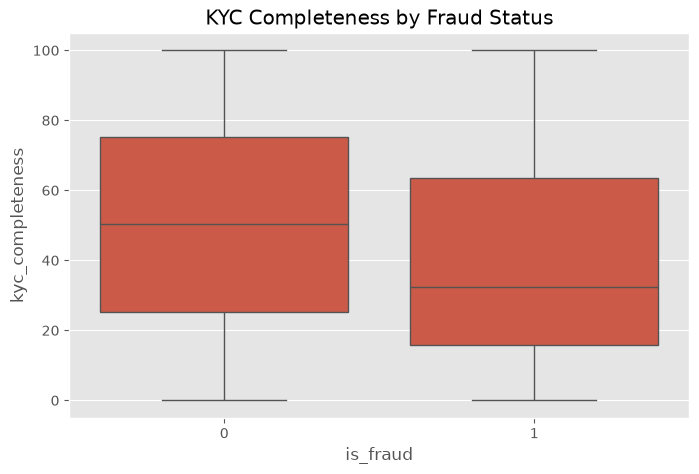

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="kyc_completeness",
    data=df
)

plt.title("KYC Completeness by Fraud Status")

plt.show()

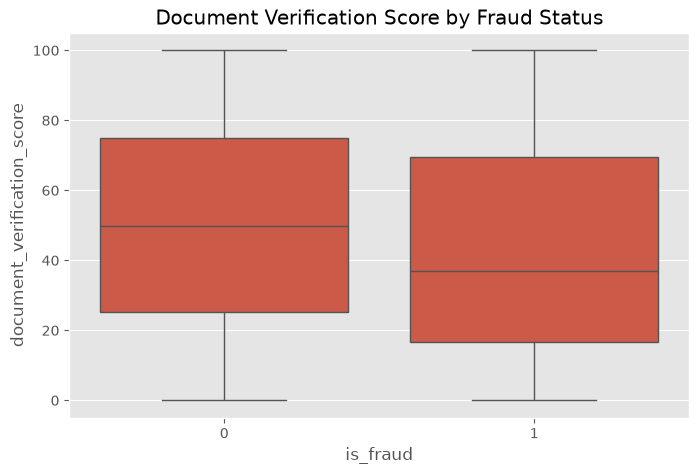

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="document_verification_score",
    data=df
)

plt.title("Document Verification Score by Fraud Status")

plt.show()

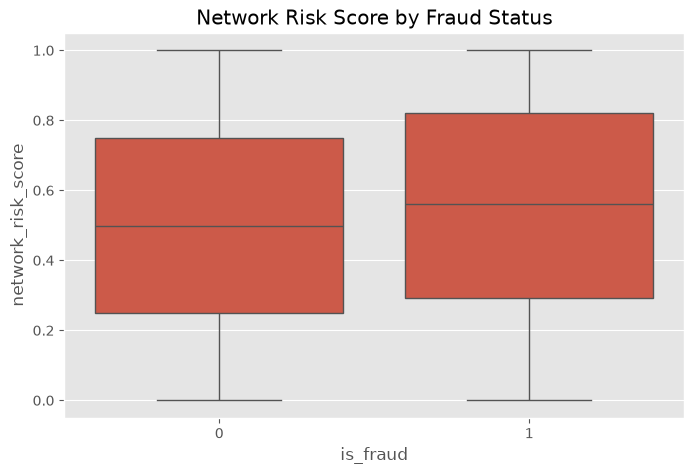

In [45]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="network_risk_score",
    data=df
)

plt.title("Network Risk Score by Fraud Status")

plt.show()

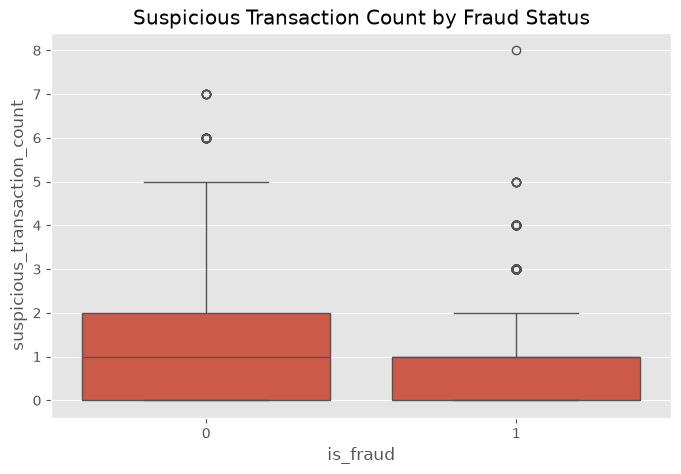

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="suspicious_transaction_count",
    data=df
)

plt.title("Suspicious Transaction Count by Fraud Status")

plt.show()

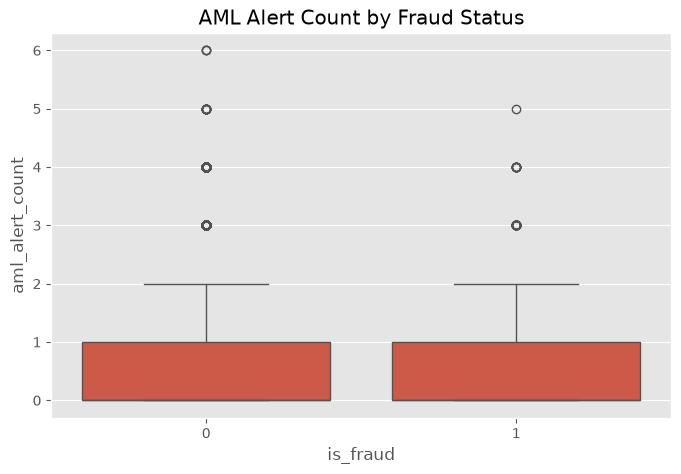

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="is_fraud",
    y="aml_alert_count",
    data=df
)

plt.title("AML Alert Count by Fraud Status")

plt.show()

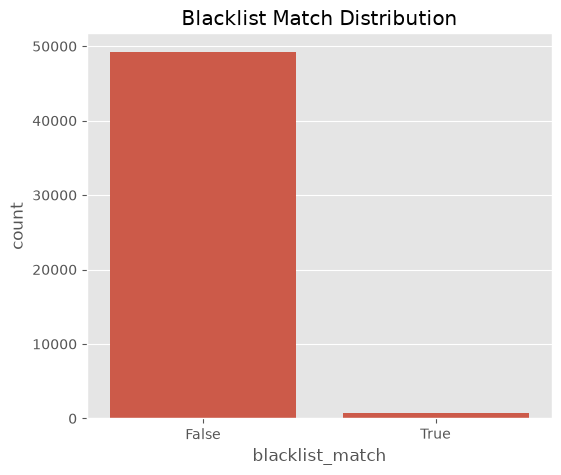

In [48]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="blacklist_match",
    data=df
)

plt.title("Blacklist Match Distribution")

plt.show()

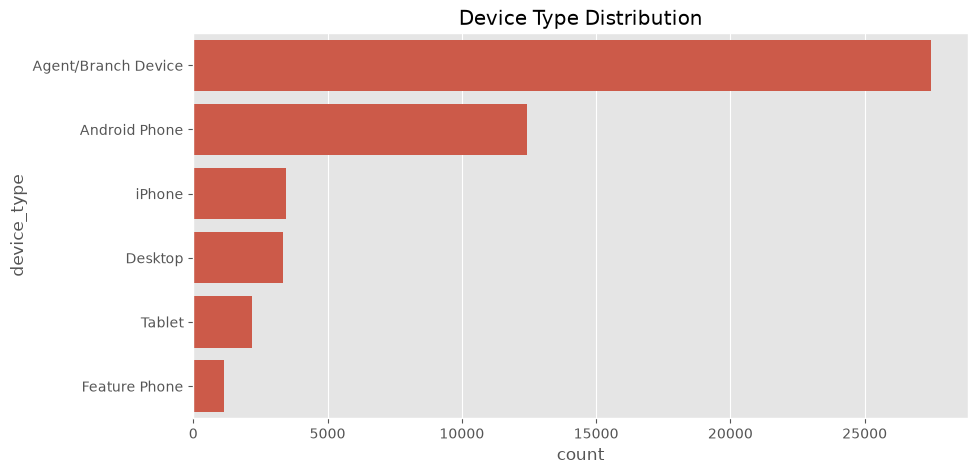

In [49]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="device_type",
    data=df,
    order=df["device_type"].value_counts().index
)

plt.title("Device Type Distribution")

plt.show()

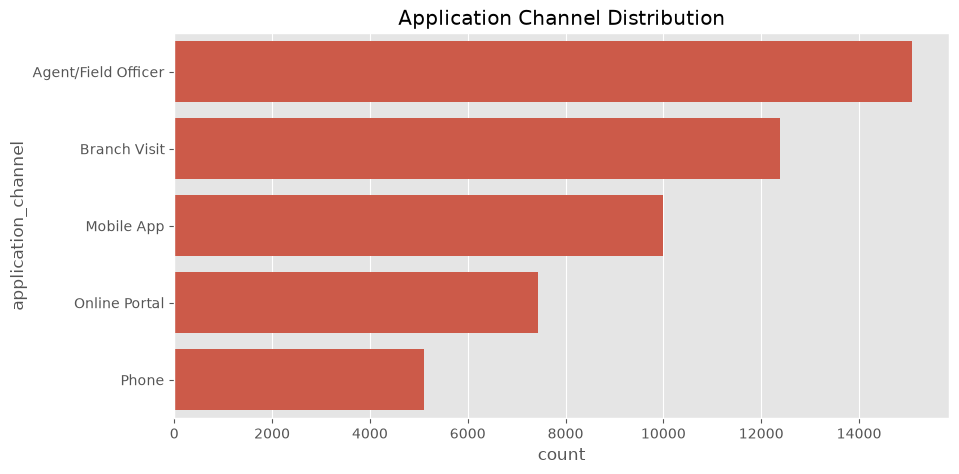

In [50]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="application_channel",
    data=df,
    order=df["application_channel"].value_counts().index
)

plt.title("Application Channel Distribution")

plt.show()

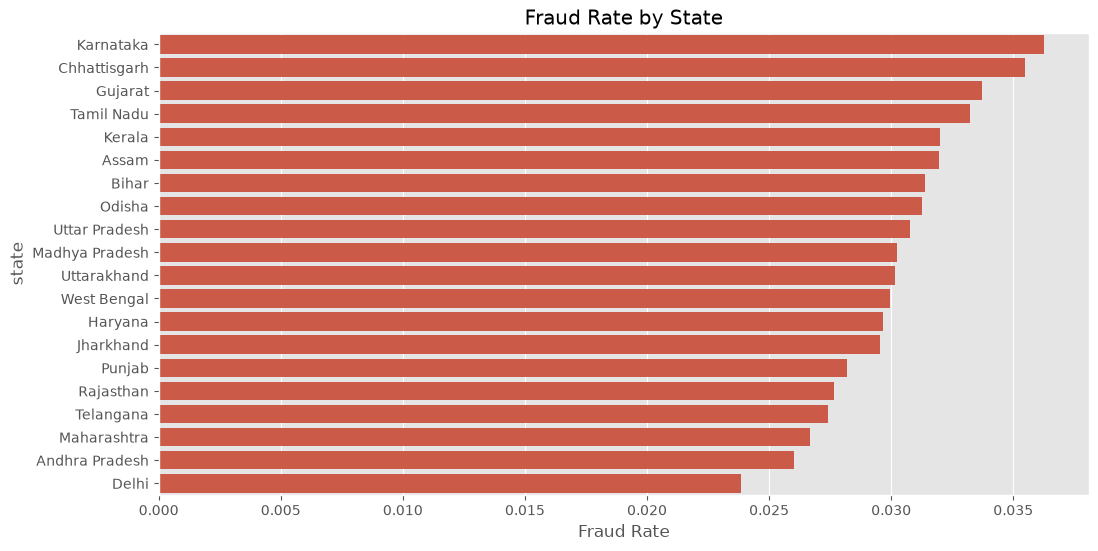

In [51]:
fraud_rate = (
    df.groupby("state")["is_fraud"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=fraud_rate,
    x="is_fraud",
    y="state"
)

plt.title("Fraud Rate by State")

plt.xlabel("Fraud Rate")

plt.show()

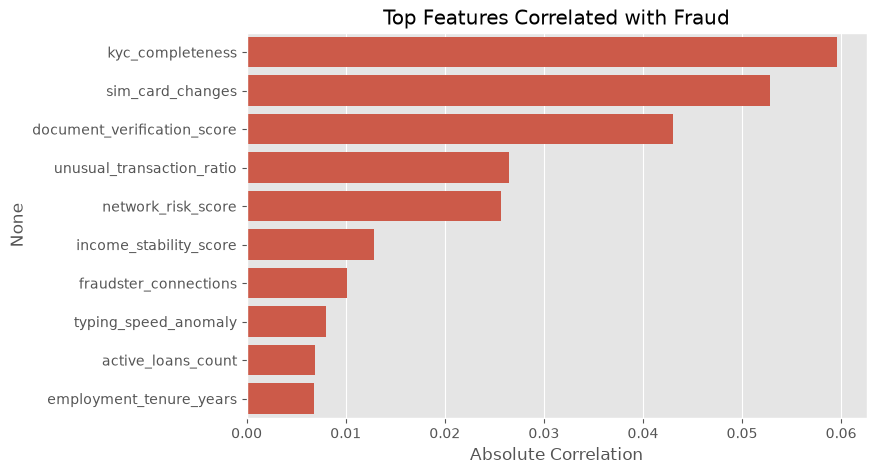

In [52]:
corr = numerical_df.corr()["is_fraud"].drop("is_fraud")

top_corr = corr.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with Fraud")

plt.xlabel("Absolute Correlation")

plt.show()

# Key Business Insights

- The dataset represents an imbalanced fraud detection problem with a low fraud rate.
- Customer demographics alone are not sufficient to identify fraud.
- Loan characteristics and credit-related variables show meaningful relationships with fraud.
- KYC, identity verification, blacklist status, and suspicious transaction indicators are important fraud risk factors.
- Digital behavior and network-related features provide additional fraud detection signals.
- Geographic differences in fraud rates suggest that region-specific monitoring may improve fraud prevention.
- Feature engineering and machine learning models are expected to capture complex relationships that are difficult to identify manually.

# EDA Conclusion

The exploratory data analysis provided a comprehensive understanding of the dataset, including customer demographics, loan information, financial behavior, compliance indicators, digital activity, and fraud-related patterns.

The insights obtained during this phase will guide feature engineering, preprocessing, and machine learning model development in the next stages of the project.

# Exploratory Data Analysis Summary

## Key Findings

### Dataset Overview

- The dataset contains 50,000 customer loan applications.
- A total of 125 features are available for analysis.
- The target variable is **is_fraud**.

---

### Fraud Distribution

- Approximately 83% of the applications are genuine.
- Approximately 17% are fraudulent.
- The dataset is moderately imbalanced.

---

### Customer Profile

- Most applicants belong to the working-age population.
- Customers belong to different occupations and geographical regions.
- Multiple education and marital status categories are represented.

---

### Financial Characteristics

- Loan amounts vary significantly across customers.
- Income distribution is positively skewed.
- Credit scores are distributed across a wide range.

---

### Risk Indicators

The dataset contains multiple fraud-related indicators including:

- KYC Completeness
- Blacklist Match
- Duplicate Applications
- AML Alerts
- Suspicious Transactions
- Income Discrepancy
- Identity Verification

These features are expected to contribute significantly during fraud prediction.

---

### Next Step

The next notebook focuses on preprocessing the data by handling categorical variables, preparing features for machine learning, and removing unnecessary columns before model training.